In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = r'/content/drive/My Drive/Colab Notebooks/Senior_Site_Planner_Test.xlsx'
raw = pd.read_excel(path)

In [4]:
df = raw.fillna(0).copy()

In [5]:
print(df)

                 City     Population  Consuming Class  Population density  \
0            An Giang  484293.582708     78216.812823          128.163687   
1   Ba Ria - Vung Tau  313168.997139     85185.549676          165.200012   
2          Binh Duong  616770.207392    126759.194403          247.863440   
3          Binh Phuoc  238539.131813     35877.685352           36.585105   
4          Binh Thuan  290245.962435     43891.697689           39.722080   
..                ...            ...              ...                 ...   
58            Da Nang  271600.553824     91618.758911          273.199890   
59            Dak Lak  452314.037943     76169.027161           36.579172   
60           Dak Nong  146578.184099     20238.349968           27.573196   
61           Dong Nai  751939.931248    150618.915168          147.768604   
62          Dong Thap  402683.173768     67969.789586          104.549269   

    F&B Spend - million\n(per capita per year)  #store  \
0                

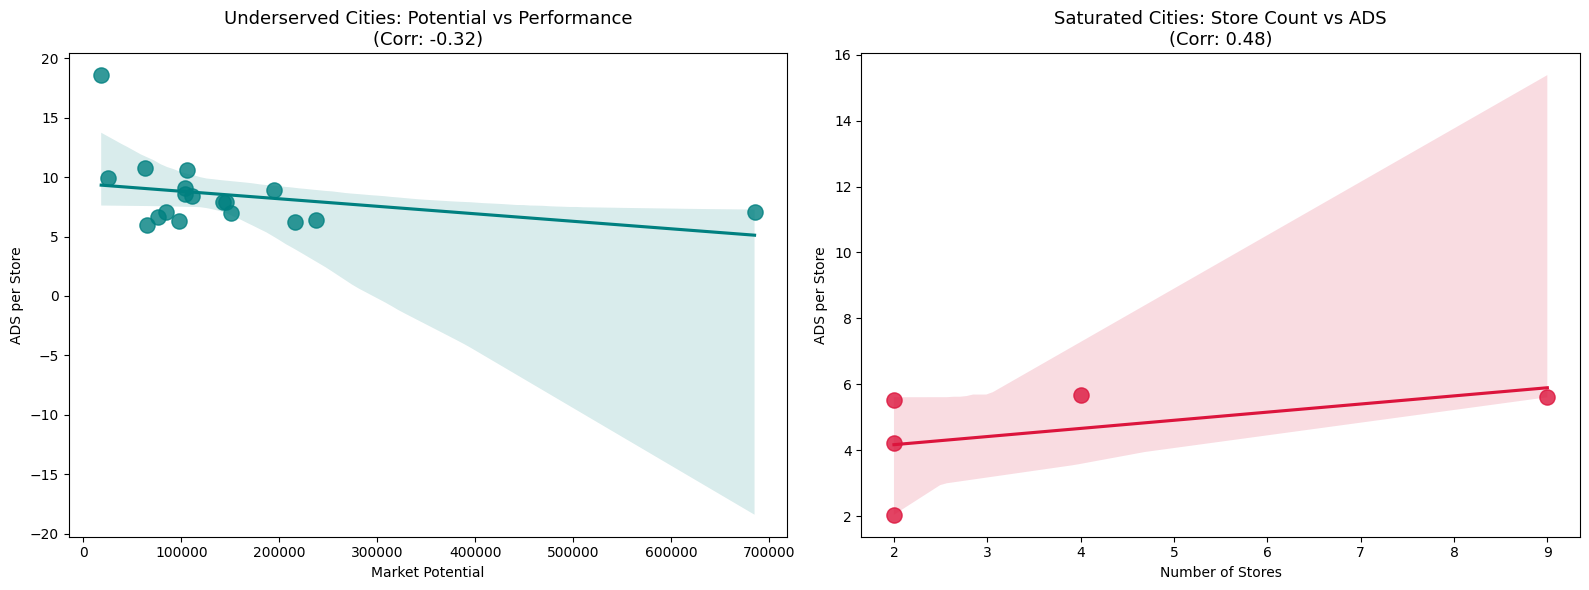

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['Market Potential'] = df['Consuming Class'] * df['F&B Spend - million\n(per capita per year)']
# 1. Split data to 2 segment
underserved_data = df[df['City Classification'] == 'Underserved']
saturated_data = df[df['City Classification'] == 'Saturated']

# 2. Chart setting up
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- for Underserved ---
# Market Potential vs. Performance
sns.regplot(ax=axes[0], x='Market Potential', y='Average Daily Sale/ store',
            data=underserved_data, color='teal', scatter_kws={'s':120})
corr_un = underserved_data['Market Potential'].corr(underserved_data['Average Daily Sale/ store'])
axes[0].set_title(f'Underserved Cities: Potential vs Performance\n(Corr: {corr_un:.2f})', fontsize=13)
axes[0].set_xlabel('Market Potential')
axes[0].set_ylabel('ADS per Store')

# --- for Saturated ---
# Store Count vs. ADS
sns.regplot(ax=axes[1], x='#store', y='Average Daily Sale/ store',
            data=saturated_data, color='crimson', scatter_kws={'s':120})
corr_sat = saturated_data['#store'].corr(saturated_data['Average Daily Sale/ store'])
axes[1].set_title(f'Saturated Cities: Store Count vs ADS\n(Corr: {corr_sat:.2f})', fontsize=13)
axes[1].set_xlabel('Number of Stores')
axes[1].set_ylabel('ADS per Store')

plt.tight_layout()
plt.show()